# Training Report — Plant Disease Detection (v2)
**Final Project Pembelajaran Mesin 2** — Farrel Ghozy Affifudin (452024611053) — TI5 A2
**Universitas Darussalam Gontor**

Eksperimen deep learning klasifikasi penyakit tanaman pada **dataset PlantVillage** (38 kelas, 54.305 citra),
dijalankan pada **NVIDIA RTX 4060 (mixed precision FP16)**.

| Exp | Model | Strategi | LR | Epoch |
|-----|-------|----------|-----|-------|
| E1 | Custom CNN (0,54M) | Dari nol (baseline) | 1e-3 | 15 |
| E2 | MobileNetV3-Small | Transfer learning, frozen | 1e-3 | 12 |
| E3 | EfficientNet-B0 | Transfer learning, frozen | 1e-3 | 12 |
| E4 | MobileNetV3-Small | Transfer learning, fine-tune | 1e-4 | 12 |

Notebook ini membaca hasil eksperimen nyata dari folder `results/` (metrics, kurva training, confusion matrix, error analysis).


In [1]:
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

# adaptif: cwd Jupyter/nbconvert = folder notebook (v2/results), fallback ke repo root
RESULTS = '.'
if not os.path.isdir(os.path.join(RESULTS, 'e1')):
    RESULTS = 'results'
assert os.path.isdir(os.path.join(RESULTS, 'e1')), f'folder e1 tidak ditemukan dari {os.getcwd()}'

rows = []
for exp in sorted(glob.glob(f'{RESULTS}/e*')):
    name = os.path.basename(exp)
    m = json.load(open(f'{exp}/metrics.json'))
    t = m['test']
    rows.append({
        'Exp': name.upper(), 'Model': m['model'], 'Strategy': m['description'],
        'Acc': round(t['accuracy'], 4), 'Prec': round(t['precision_macro'], 4),
        'Rec': round(t['recall_macro'], 4), 'F1': round(t['f1_macro'], 4),
        'BestEpoch': m['config']['best_epoch'], 'EpochsRun': m['config'].get('epochs_ran', len(json.load(open(f'{exp}/history.json'))['train_loss'])),
        'TrainTime(s)': round(m['train_seconds']),
        'ParamsTrainable': f"{m['params']['trainable']:,}",
    })
df = pd.DataFrame(rows)
display(df.style.highlight_max(subset=['Acc', 'Prec', 'Rec', 'F1'], color='#c8e6c9'))
print('\nRata-rata waktu per epoch (detik):')
df['sec/epoch'] = df['TrainTime(s)'] / df['EpochsRun']
print(df[['Exp', 'sec/epoch']].to_string(index=False))


,Exp,Model,Strategy,Acc,Prec,Rec,F1,BestEpoch,EpochsRun,TrainTime(s),ParamsTrainable
0,E1,e1_custom_cnn,Custom CNN baseline (from scratch),0.950900,0.948500,0.931700,0.933900,14,15,717,"540,454"
1,E2,e2_mobilenetv3,"MobileNetV3-Small TL, backbone frozen",0.974700,0.967900,0.961800,0.964100,12,12,497,"629,798"
2,E3,e3_efficientnet,"EfficientNet-B0 TL, backbone frozen",0.949800,0.941700,0.931900,0.934800,11,12,518,"48,678"
3,E4,e4_mobilenetv3_ft,"MobileNetV3-Small TL, fine-tune penuh",0.989900,0.988100,0.981500,0.984200,6,10,495,"1,556,806"



Rata-rata waktu per epoch (detik):
Exp  sec/epoch
 E1  47.800000
 E2  41.416667
 E3  43.166667
 E4  49.500000


## Kurva Training & Validasi
Gambar di bawah adalah kurva loss dan accuracy dari proses training nyata (bukan simulasi).


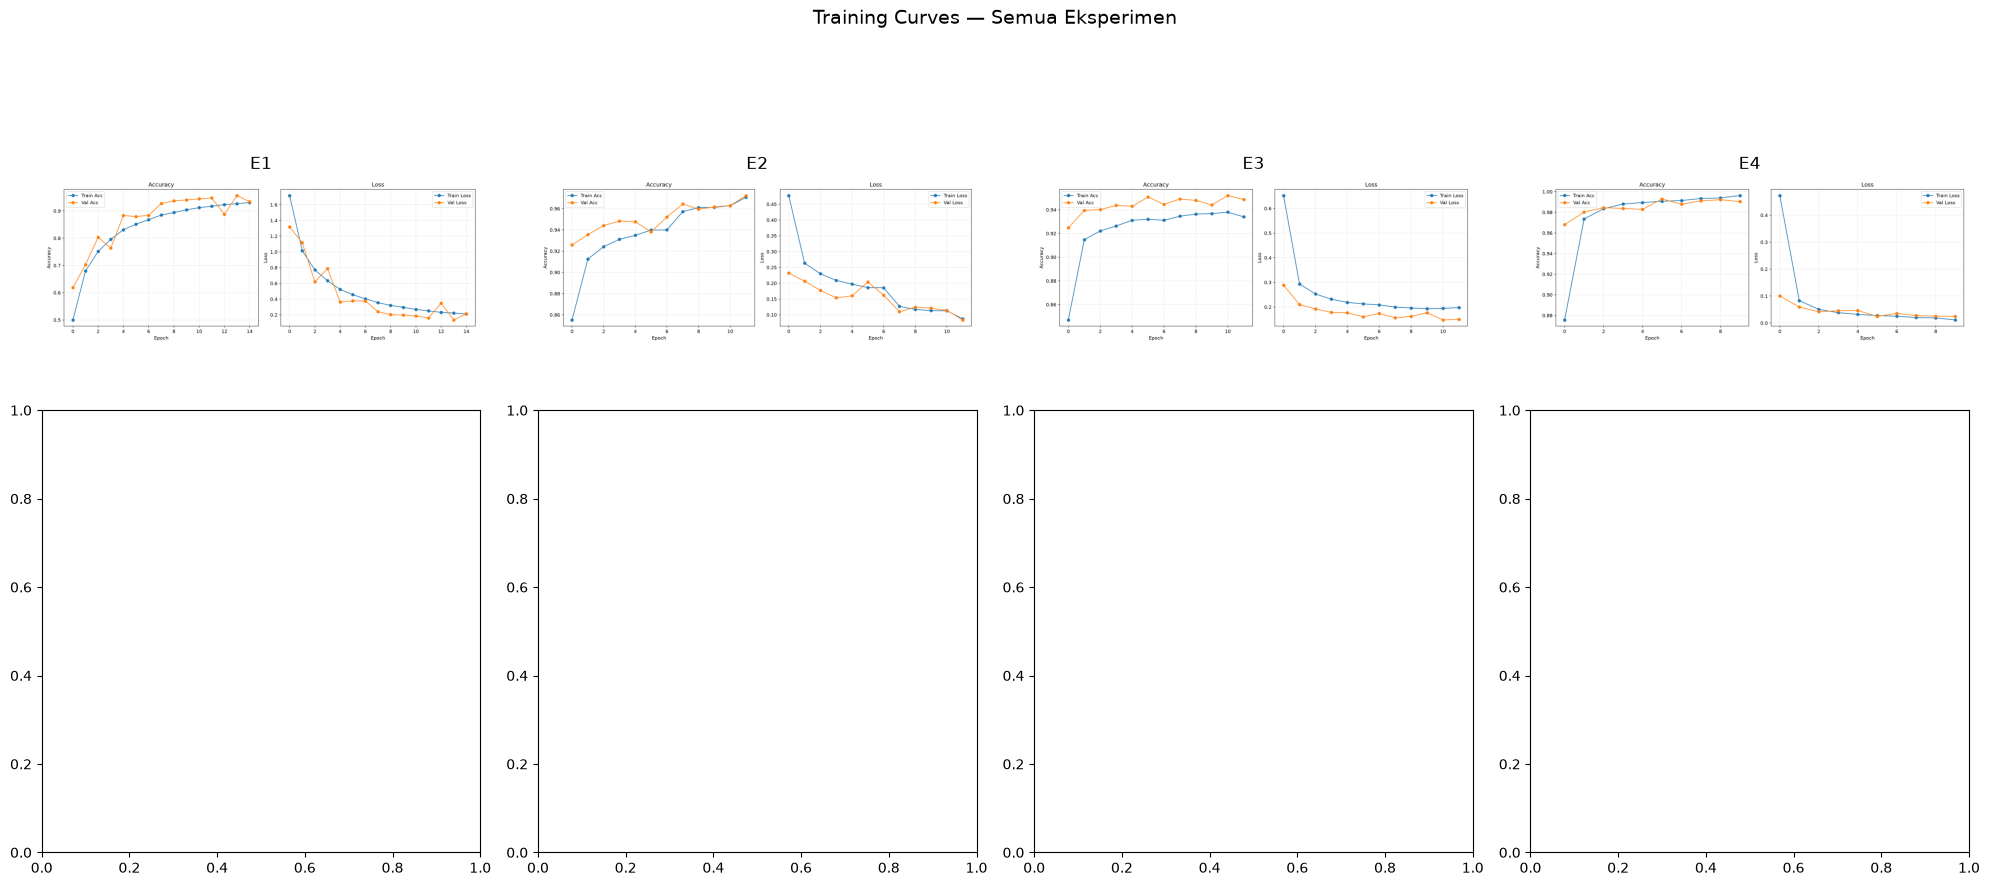

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
exps = ['e1','e2','e3','e4']
for i, e in enumerate(exps):
    path = f'{RESULTS}/{e}/training_curves.png'
    if not os.path.exists(path):
        axes[0,i].set_title(f'{e.upper()} (belum ada)')
        continue
    img = mpimg.imread(path)
    axes[0,i].imshow(img); axes[0,i].axis('off'); axes[0,i].set_title(e.upper())
fig.suptitle('Training Curves — Semua Eksperimen', fontsize=14)
plt.tight_layout(); plt.show()

## Confusion Matrix (Test Set)


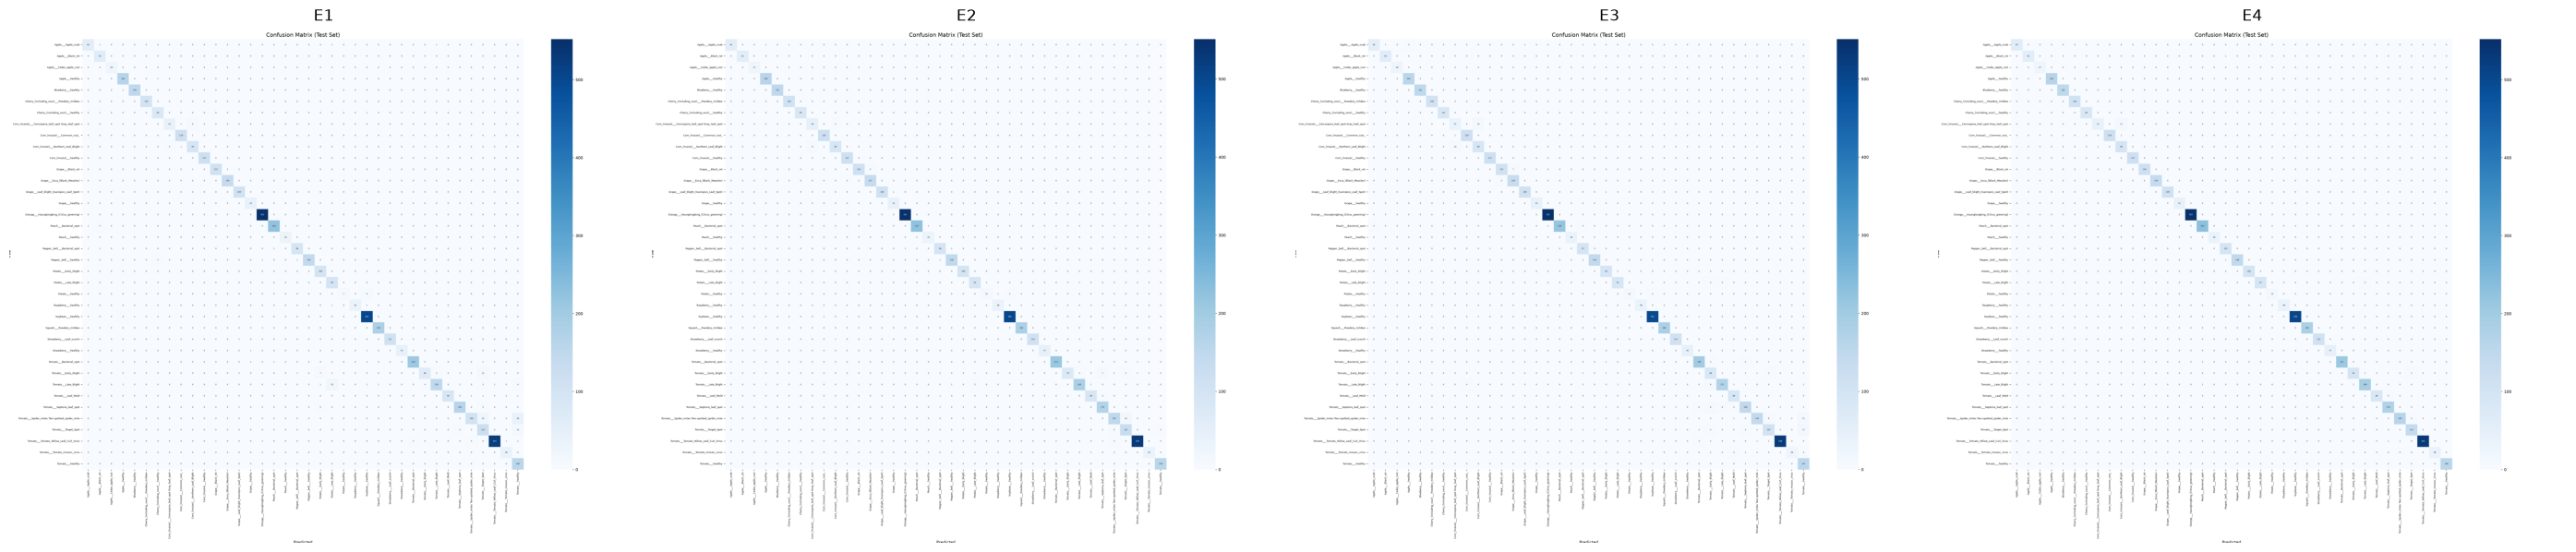

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(28, 9))
for i, e in enumerate(exps):
    path = f'{RESULTS}/{e}/confusion_matrix.png'
    if not os.path.exists(path):
        axes[i].set_title(f'{e.upper()} (belum ada)')
        continue
    img = mpimg.imread(path)
    axes[i].imshow(img); axes[i].axis('off'); axes[i].set_title(e.upper())
plt.tight_layout(); plt.show()

## Error Analysis
### Akurasi per kelas — 10 terbaik & 10 terburuk (model terbaik)


In [4]:
best = df.sort_values('F1', ascending=False).iloc[0]['Exp'].lower()
info = json.load(open(f'{RESULTS}/{best}/per_class_analysis.json'))
print(f'=== Model terbaik: {best.upper()} (F1={df.sort_values("F1", ascending=False).iloc[0]["F1"]}) ===')
print('\n-- 10 kelas TERBURUK --')
for x in info['worst']: print(f"  {x['class']}: {x['acc']:.4f}")
print('\n-- 10 kelas TERBAIK --')
for x in info['best']: print(f"  {x['class']}: {x['acc']:.4f}")

=== Model terbaik: E4 (F1=0.9842) ===

-- 10 kelas TERBURUK --
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 0.7885
  Potato___healthy: 0.8750
  Tomato___Leaf_Mold: 0.8958
  Tomato___Early_blight: 0.9300
  Apple___Cedar_apple_rust: 0.9643
  Potato___Late_blight: 0.9700
  Tomato___Spider_mites Two-spotted_spider_mite: 0.9763
  Apple___Black_rot: 0.9841
  Tomato___Bacterial_spot: 0.9860
  Cherry_(including_sour)___healthy: 0.9884

-- 10 kelas TERBAIK --
  Apple___Apple_scab: 1.0000
  Blueberry___healthy: 1.0000
  Cherry_(including_sour)___Powdery_mildew: 1.0000
  Corn_(maize)___healthy: 1.0000
  Grape___Black_rot: 1.0000
  Grape___Esca_(Black_Measles): 1.0000
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1.0000
  Grape___healthy: 1.0000
  Orange___Haunglongbing_(Citrus_greening): 1.0000
  Peach___Bacterial_spot: 1.0000


### Top-25 kesalahan dengan confidence tertinggi (model salah tapi yakin)
Ini sampel misclassification yang paling "yakin" — berguna untuk memahami pola kesalahan model.


In [5]:
errs = json.load(open(f'{RESULTS}/{best}/top_errors.json'))
for i, e in enumerate(errs[:10], 1):
    print(f"{i:2d}. {os.path.basename(e['path'])[:55]:55s} true={e['true'][:30]:30s} pred={e['pred'][:30]:30s} conf={e['confidence']:.3f}")

 1. 413bc2e9-eb2a-48fd-ba65-48b5121fd85c___RS_HL 4200.JPG   true=Potato___healthy               pred=Apple___healthy                conf=0.320
 2. 3046afbf-4a9a-41fb-a64f-3f9e75af08e7___Com.G_SpM_FL 162 true=Tomato___Spider_mites Two-spot pred=Peach___Bacterial_spot         conf=0.356
 3. f88be630-f853-48f8-b546-a2f7966368a2___RS_Erly.B 7418.J true=Tomato___Early_blight          pred=Tomato___Late_blight           conf=0.377
 4. 2565077d-44d3-4213-82c2-bf5ae9a64368___RS_LB 3295.JPG   true=Potato___Late_blight           pred=Tomato___Late_blight           conf=0.465
 5. 9c89a858-83de-4074-96fd-bde5f9e4acdc___Crnl_L.Mold 6905 true=Tomato___Leaf_Mold             pred=Tomato___Tomato_mosaic_virus   conf=0.496
 6. bcab5afc-96ce-4b88-8801-8e905b783ef3___Crnl_L.Mold 9094 true=Tomato___Leaf_Mold             pred=Tomato___Septoria_leaf_spot    conf=0.496
 7. 2252552c-aa8f-45a4-8c26-f79fa3febf9d___Com.G_SpM_FL 895 true=Tomato___Spider_mites Two-spot pred=Tomato___Target_Spot           conf=0.501

## Classification Report (per kelas, model terbaik)


In [6]:
print(open(f'{RESULTS}/{best}/classification_report.txt').read())

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000        63
                                 Apple___Black_rot     1.0000    0.9841    0.9920        63
                          Apple___Cedar_apple_rust     1.0000    0.9643    0.9818        28
                                   Apple___healthy     0.9939    0.9939    0.9939       165
                               Blueberry___healthy     1.0000    1.0000    1.0000       151
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       106
                 Cherry_(including_sour)___healthy     1.0000    0.9884    0.9942        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9762    0.7885    0.8723        52
                       Corn_(maize)___Common_rust_     1.0000    0.9917    0.9958       120
               Corn_(maize)___Northern_Leaf_Blight     0.8909    0.9899    0.93

---
*Seluruh hasil di atas bersumber dari eksperimen nyata yang dijalankan di GPU lokal (RTX 4060).
Log training lengkap: `results/run_all.log`. Checkpoint model: `~/pm2_v2/models/<exp>_best.pt`.*